# 02 Exploratory analysis

Reads the cleaned listings written by `python -m house_prices.clean`. Every statement in the final section is
computed from the data shown above it.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from house_prices import clean, config, load

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")
config.PATHS.figures_dir.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    fig.savefig(config.PATHS.figures_dir / f"{name}.png", dpi=140, bbox_inches="tight")

In [2]:
import plotly.express as px

listings = pd.read_parquet(config.PATHS.listings)
listings["ppsf"] = listings["price"] / listings["area_sqft"]
listings["price_crore"] = listings["price"] / 1e7
print(f"{len(listings):,} cleaned listings, {listings['date_added'].min().date()} to {listings['date_added'].max().date()}")
listings.head()

67,073 cleaned listings, 2018-08-05 to 2019-08-06


,listing_id,property_type,price,location,city,province,latitude,longitude,baths,bedrooms,area_sqft,area_value,area_unit_norm,date_added,ppsf,price_crore
0,0,House,40000000.0,Multan Road,Lahore,Punjab,31.431593,74.179980,5,5,5445.00,NaN,kanal,2018-10-06,7346.189164,4.00
1,1,House,9500000.0,Eden,Lahore,Punjab,31.499348,74.416959,0,3,2450.25,NaN,marla,2019-07-03,3877.155392,0.95
2,2,House,125000000.0,Gulberg,Lahore,Punjab,31.522069,74.355512,7,8,5445.00,NaN,kanal,2019-04-04,22956.841139,12.50
3,3,House,21000000.0,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,6,2994.75,NaN,marla,2019-04-04,7012.271475,2.10
4,4,House,52000000.0,Gulberg,Lahore,Punjab,31.495909,74.350569,6,5,5445.00,NaN,kanal,2019-06-02,9550.045914,5.20


## Price distribution: linear and log scale

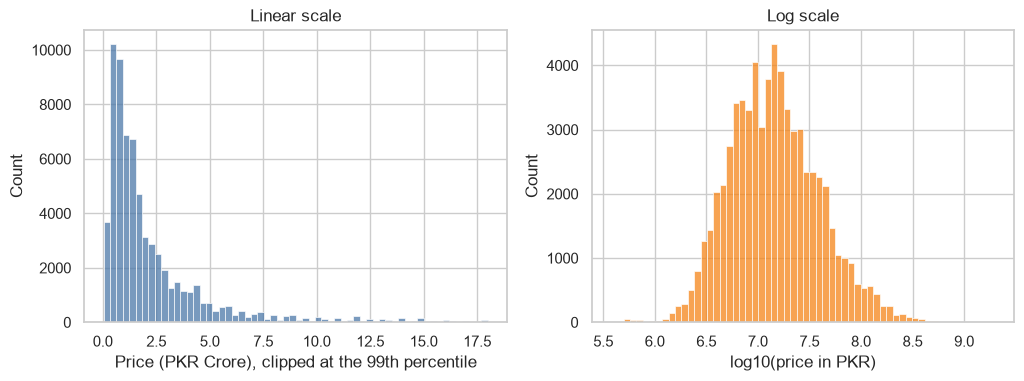

Skewness of price: 9.21; skewness of log price: 0.33


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
cap = listings["price_crore"].quantile(0.99)
sns.histplot(listings.loc[listings["price_crore"] <= cap, "price_crore"], bins=60, ax=axes[0], color="#4c78a8")
axes[0].set_xlabel("Price (PKR Crore), clipped at the 99th percentile")
axes[0].set_title("Linear scale")
sns.histplot(np.log10(listings["price"]), bins=60, ax=axes[1], color="#f58518")
axes[1].set_xlabel("log10(price in PKR)")
axes[1].set_title("Log scale")
save_fig(fig, "eda_price_distribution")
plt.show()
print(f"Skewness of price: {listings['price'].skew():.2f}; skewness of log price: {np.log(listings['price']).skew():.2f}")

## Price per sq ft by city and by property type

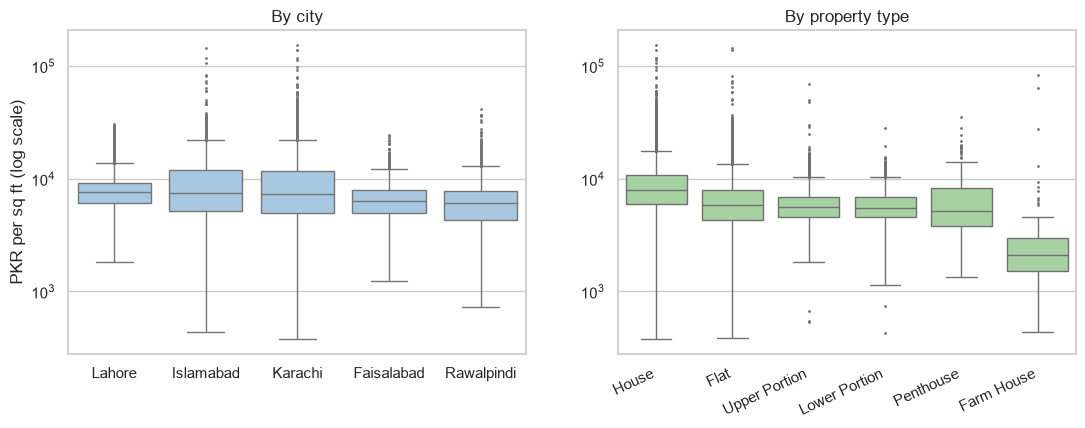

,count,median
city,,
Lahore,23119,7629.0
Islamabad,10345,7543.0
Karachi,25039,7346.0
Faisalabad,1870,6297.0
Rawalpindi,6700,6061.0


In [4]:
order = listings.groupby("city")["ppsf"].median().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.boxplot(data=listings, x="city", y="ppsf", order=order, ax=axes[0], color="#9ecae9", fliersize=1)
axes[0].set_yscale("log")
axes[0].set_ylabel("PKR per sq ft (log scale)")
axes[0].set_xlabel("")
axes[0].set_title("By city")
type_order = listings.groupby("property_type")["ppsf"].median().sort_values(ascending=False).index
sns.boxplot(data=listings, x="property_type", y="ppsf", order=type_order, ax=axes[1], color="#a1d99b", fliersize=1)
axes[1].set_yscale("log")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].set_title("By property type")
plt.setp(axes[1].get_xticklabels(), rotation=25, ha="right")
save_fig(fig, "eda_ppsf_city_type")
plt.show()
display(listings.groupby("city")["ppsf"].agg(["count", "median"]).round(0).sort_values("median", ascending=False))

## Most and least expensive locations

Median price per sq ft for Karachi, Lahore and Islamabad, only for locations with at least
`MIN_LOCATION_COUNT` listings so a handful of listings cannot decide the ranking.

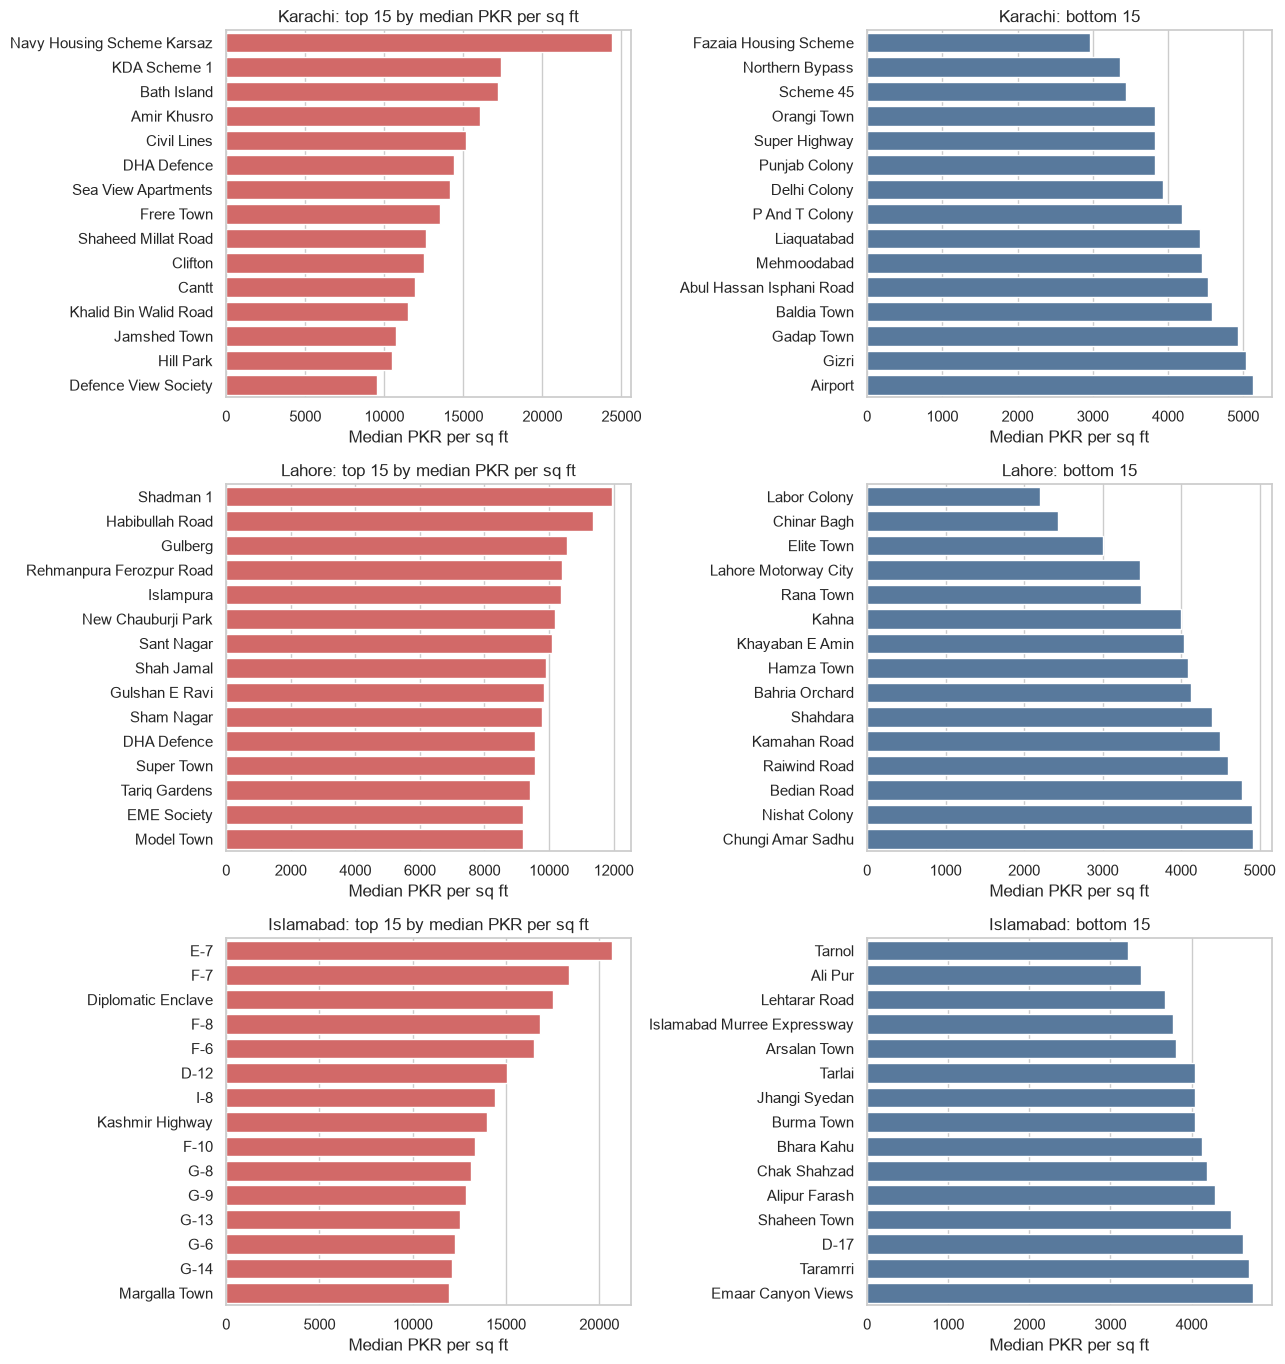

{'Karachi': 63, 'Lahore': 163, 'Islamabad': 65} locations with enough listings


In [5]:
min_count = config.MIN_LOCATION_COUNT
focus = [c for c in ("Karachi", "Lahore", "Islamabad") if c in set(listings["city"])]
fig, axes = plt.subplots(len(focus), 2, figsize=(13, 4.6 * len(focus)), squeeze=False)
location_tables = {}
for row, city in enumerate(focus):
    sub = listings[listings["city"] == city]
    stats = sub.groupby("location")["ppsf"].agg(["count", "median"])
    stats = stats[stats["count"] >= min_count].sort_values("median", ascending=False)
    location_tables[city] = stats
    n = min(15, len(stats))
    top, bottom = stats.head(n), stats.tail(n).sort_values("median")
    sns.barplot(x=top["median"], y=top.index, ax=axes[row, 0], color="#e45756")
    axes[row, 0].set_title(f"{city}: top {n} by median PKR per sq ft")
    sns.barplot(x=bottom["median"], y=bottom.index, ax=axes[row, 1], color="#4c78a8")
    axes[row, 1].set_title(f"{city}: bottom {n}")
    for ax in axes[row]:
        ax.set_xlabel("Median PKR per sq ft")
        ax.set_ylabel("")
fig.tight_layout()
save_fig(fig, "eda_location_rankings")
plt.show()
print({city: len(t) for city, t in location_tables.items()}, "locations with enough listings")

## Price versus size and versus bedrooms

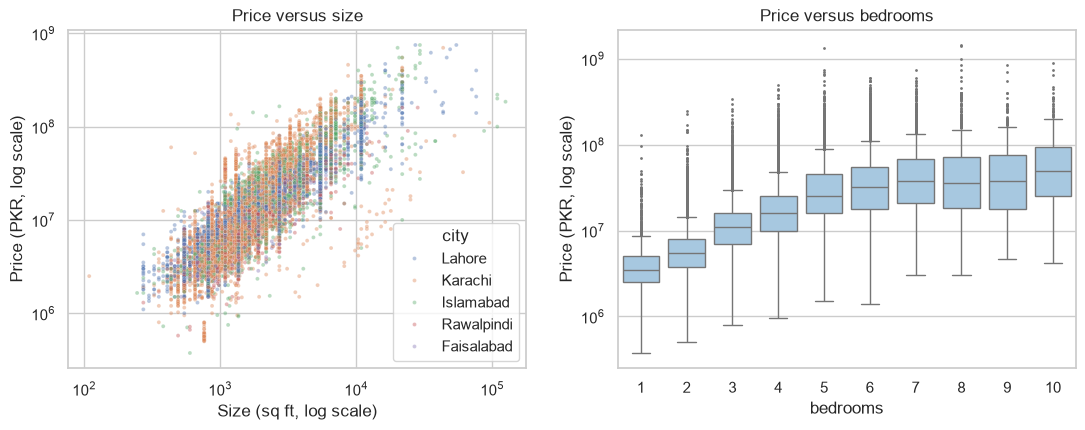

,Pearson
log price vs log size,0.857
log price vs bedrooms,0.635
log price vs baths,0.515
log size vs bedrooms,0.584


,Spearman with price
price,1.000
area_sqft,0.856
bedrooms,0.683
baths,0.558


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
sample = listings.sample(min(len(listings), 20000), random_state=config.RANDOM_STATE)
sns.scatterplot(data=sample, x="area_sqft", y="price", hue="city", s=8, alpha=0.4, ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Size (sq ft, log scale)")
axes[0].set_ylabel("Price (PKR, log scale)")
axes[0].set_title("Price versus size")
bed = listings[listings["bedrooms"] <= 10]
sns.boxplot(data=bed, x="bedrooms", y="price", ax=axes[1], color="#9ecae9", fliersize=1)
axes[1].set_yscale("log")
axes[1].set_title("Price versus bedrooms")
axes[1].set_ylabel("Price (PKR, log scale)")
save_fig(fig, "eda_price_size_bedrooms")
plt.show()
corr = pd.Series(
    {
        "log price vs log size": np.corrcoef(np.log(listings["price"]), np.log(listings["area_sqft"]))[0, 1],
        "log price vs bedrooms": np.corrcoef(np.log(listings["price"]), listings["bedrooms"])[0, 1],
        "log price vs baths": np.corrcoef(np.log(listings["price"]), listings["baths"])[0, 1],
        "log size vs bedrooms": np.corrcoef(np.log(listings["area_sqft"]), listings["bedrooms"])[0, 1],
    }
)
spearman = listings[["price", "area_sqft", "bedrooms", "baths"]].corr(method="spearman")["price"]
display(corr.round(3).to_frame("Pearson"))
display(spearman.round(3).to_frame("Spearman with price"))

Bedrooms and size move together (see the last Pearson row), so bedrooms carry a good part of the size signal;
the modelling notebook checks how much each adds on its own.

## Map of median price per sq ft

In [7]:
geo = listings.dropna(subset=["latitude", "longitude"])
spots = (
    geo.groupby(["city", "location"])
    .agg(latitude=("latitude", "median"), longitude=("longitude", "median"), ppsf=("ppsf", "median"), listings=("ppsf", "size"))
    .reset_index()
)
spots = spots[spots["listings"] >= 5]
print(f"{len(spots):,} locations plotted from {len(geo):,} listings with coordinates")
fig_map = px.scatter_map(
    spots,
    lat="latitude",
    lon="longitude",
    color="ppsf",
    size="listings",
    size_max=22,
    hover_name="location",
    hover_data={"city": True, "ppsf": ":,.0f", "listings": True, "latitude": False, "longitude": False},
    color_continuous_scale="Viridis",
    zoom=4.3,
    center={"lat": 30.3, "lon": 70.0},
    map_style="open-street-map",
    height=620,
    title="Median PKR per sq ft by location",
)
fig_map.update_layout(margin={"l": 0, "r": 0, "t": 40, "b": 0})
fig_map.write_html(config.PATHS.figures_dir / "price_map.html", include_plotlyjs="cdn")
fig_map.show()

866 locations plotted from 67,057 listings with coordinates


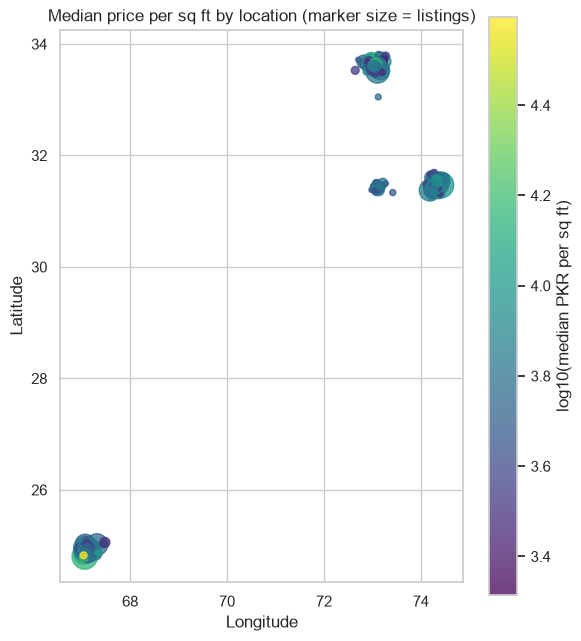

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 7.5))
scatter = ax.scatter(spots["longitude"], spots["latitude"], c=np.log10(spots["ppsf"]), s=np.sqrt(spots["listings"]) * 6, cmap="viridis", alpha=0.75)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("log10(median PKR per sq ft)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Median price per sq ft by location (marker size = listings)")
ax.set_aspect(1.15)
save_fig(fig, "price_map")
plt.show()

## Listing counts over time

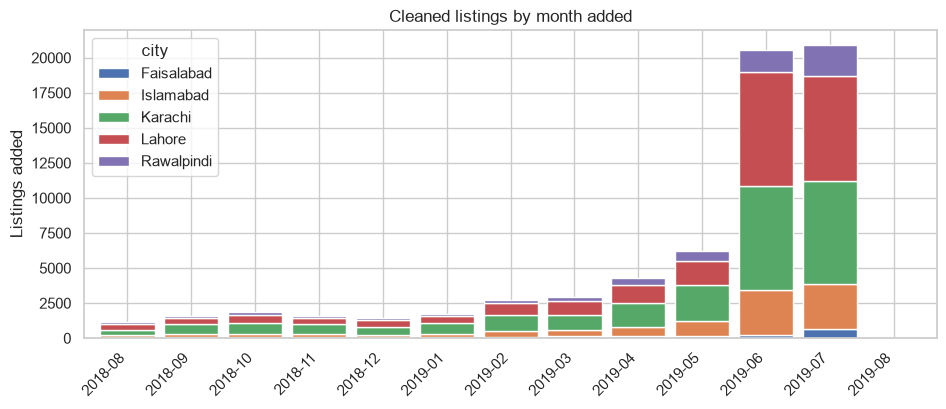

Data covers 2018-08-05 to 2019-08-06 (366 days)


In [9]:
monthly = listings.assign(month=listings["date_added"].dt.to_period("M").dt.to_timestamp())
counts = monthly.groupby(["month", "city"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(11, 4))
counts.plot.bar(stacked=True, ax=ax, width=0.85)
ax.set_xticklabels([d.strftime("%Y-%m") for d in counts.index], rotation=45, ha="right")
ax.set_ylabel("Listings added")
ax.set_xlabel("")
ax.set_title("Cleaned listings by month added")
save_fig(fig, "eda_listings_over_time")
plt.show()
print(f"Data covers {listings['date_added'].min().date()} to {listings['date_added'].max().date()} "
      f"({(listings['date_added'].max() - listings['date_added'].min()).days} days)")

## What the data shows

Each sentence below is generated from the numbers plotted above, so it can only report what the charts contain.

In [10]:
by_city = listings.groupby("city")["ppsf"].median().sort_values(ascending=False)
by_type = listings.groupby("property_type")["ppsf"].median().sort_values(ascending=False)
share = listings["city"].value_counts(normalize=True)
days = (listings["date_added"].max() - listings["date_added"].min()).days
lines = [
    f"The file has {len(listings):,} cleaned for-sale listings added between {listings['date_added'].min().date()} and {listings['date_added'].max().date()} ({days} days).",
    f"{share.index[0]} has the most listings ({share.iloc[0]:.0%}); {share.index[-1]} has the fewest ({share.iloc[-1]:.0%}).",
    f"Median price per sq ft is highest in {by_city.index[0]} (PKR {by_city.iloc[0]:,.0f}) and lowest in {by_city.index[-1]} (PKR {by_city.iloc[-1]:,.0f}), a ratio of {by_city.iloc[0] / by_city.iloc[-1]:.1f}x.",
    f"By property type, median price per sq ft is highest for {by_type.index[0]} (PKR {by_type.iloc[0]:,.0f}) and lowest for {by_type.index[-1]} (PKR {by_type.iloc[-1]:,.0f}).",
    f"Price is right-skewed (skewness {listings['price'].skew():.1f}); on a log scale the skewness is {np.log(listings['price']).skew():.1f}, which is why the model predicts log price.",
    f"Log price and log size have a Pearson correlation of {corr['log price vs log size']:.2f}; log price and bedrooms {corr['log price vs bedrooms']:.2f}.",
]
for city, stats in location_tables.items():
    if len(stats) >= 2:
        lines.append(
            f"Within {city}, the priciest well-covered location is {stats.index[0]} (median PKR {stats['median'].iloc[0]:,.0f} per sq ft) and the cheapest is {stats.index[-1]} (PKR {stats['median'].iloc[-1]:,.0f}), {stats['median'].iloc[0] / stats['median'].iloc[-1]:.1f}x apart."
        )
print("\n".join("- " + line for line in lines))

- The file has 67,073 cleaned for-sale listings added between 2018-08-05 and 2019-08-06 (366 days).
- Karachi has the most listings (37%); Faisalabad has the fewest (3%).
- Median price per sq ft is highest in Lahore (PKR 7,629) and lowest in Rawalpindi (PKR 6,061), a ratio of 1.3x.
- By property type, median price per sq ft is highest for House (PKR 7,949) and lowest for Farm House (PKR 2,109).
- Price is right-skewed (skewness 9.2); on a log scale the skewness is 0.3, which is why the model predicts log price.
- Log price and log size have a Pearson correlation of 0.86; log price and bedrooms 0.63.
- Within Karachi, the priciest well-covered location is Navy Housing Scheme Karsaz (median PKR 24,381 per sq ft) and the cheapest is Fazaia Housing Scheme (PKR 2,968), 8.2x apart.
- Within Lahore, the priciest well-covered location is Shadman 1 (median PKR 11,938 per sq ft) and the cheapest is Labor Colony (PKR 2,204), 5.4x apart.
- Within Islamabad, the priciest well-covered location is E